In [1]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

# Load the Netflix dataset
df = pd.read_csv('/content/drive/MyDrive/netflix_titles.csv')

# checking if data loaded by seeing 5 rows
df.head()

Mounted at /content/drive


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# Check total missing values in each column before cleaning
print("--- Missing Values BEFORE Cleaning ---")
print(df.isnull().sum())

--- Missing Values BEFORE Cleaning ---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [ ]:
# Fill missing text columns with 'Unknown' or 'Not Rated'
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

# Drop rows where essential date or duration is completely missing
df.dropna(subset=['date_added', 'duration'], inplace=True)

In [ ]:
# Check missing values after cleaning
print("\n--- Missing Values AFTER Cleaning ---")
print(df.isnull().sum())

# Check final dataset shape (Rows, Columns)
print("\nFinal Dataset Shape:", df.shape)


--- Missing Values AFTER Cleaning ---
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Final Dataset Shape: (8794, 12)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Check unique values in the 'type' column before encoding
print("Before encoding:", df['type'].unique())

Before encoding: ['Movie' 'TV Show']


In [ ]:
# Initialize the Label Encoder
label_encoder = LabelEncoder()

# Convert categorical text column into numeric values
df['type_encoded'] = label_encoder.fit_transform(df['type'])

# Display the original and encoded columns to verify
print(df[['type', 'type_encoded']].head())

      type  type_encoded
0    Movie             0
1  TV Show             1
2  TV Show             1
3  TV Show             1
4  TV Show             1


In [ ]:
# We can also encode the 'rating' column into numbers using Label Encoder
df['rating_encoded'] = label_encoder.fit_transform(df['rating'])

# Check the first few rows with the new encoded column
print(df[['rating', 'rating_encoded']].head())

  rating  rating_encoded
0  PG-13               5
1  TV-MA               9
2  TV-MA               9
3  TV-MA               9
4  TV-MA               9


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF Vectorizer
# stop_words='english' removes common words like 'the', 'is', 'at' to keep only important words
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

In [ ]:
# Fill any remaining empty descriptions with blank text just in case
df['description'] = df['description'].fillna('')

# Fit and transform the description column into numerical matrix
tfidf_matrix_desc = tfidf.fit_transform(df['description'])

# Check the shape of the resulting matrix
print("TF-IDF Matrix Shape for Description:", tfidf_matrix_desc.shape)

TF-IDF Matrix Shape for Description: (8794, 5000)


In [ ]:
# Fill any empty genres with blank text
df['listed_in'] = df['listed_in'].fillna('')

# Fit and transform the listed_in column
tfidf_matrix_genres = tfidf.fit_transform(df['listed_in'])

# Check the shape of the genres matrix
print("TF-IDF Matrix Shape for Genres:", tfidf_matrix_genres.shape)

TF-IDF Matrix Shape for Genres: (8794, 44)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Calculate cosine similarity matrix based on descriptions
cosine_sim = cosine_similarity(tfidf_matrix_desc, tfidf_matrix_desc)

print("Cosine Similarity Matrix computed successfully!")

Cosine Similarity Matrix computed successfully!


In [ ]:
# Create mapping between movie titles and dataframe indices
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [ ]:
# Function to get movie recommendations
def get_recommendations(title, cosine_sim=cosine_sim):
    if title not in indices:
        return "Movie title not found in dataset!"

    # Get the index of the movie
    idx = indices[title]

    # Get similarity scores for all movies
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort movies based on similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get top 5 similar movies (excluding the searched movie itself)
    sim_scores = sim_scores[1:6]
    movie_indices = [i[0] for i in sim_scores]

    # Return recommendations
    return df[['title', 'type', 'listed_in']].iloc[movie_indices]

# Interactive recommendation where you can enter any title at runtime
user_input_title = input("Enter a Netflix Movie / TV Show Title: ")

# Get recommendations based on user input
print(f"\nRecommendations for '{user_input_title}':\n")
result = get_recommendations(user_input_title)
print(result)

Enter a Netflix Movie / TV Show Title: Ganglands

Recommendations for 'Ganglands':

                                  title     type  \
424   Chhota Bheem: The Rise of Kirmada    Movie   
5113                             Bright    Movie   
3451                  Kids on the Block    Movie   
6592                     Den of Thieves    Movie   
5305                             Narcos  TV Show   

                                             listed_in  
424                           Children & Family Movies  
5113              Action & Adventure, Sci-Fi & Fantasy  
3451                Children & Family Movies, Comedies  
6592                                Action & Adventure  
5305  Crime TV Shows, TV Action & Adventure, TV Dramas  


Shamita G K - supervised ML algorithms

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from google.colab import files
from IPython.display import display

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


,Number of Titles
country,
United States,3689
India,1046
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231
Germany,226


Most frequent country: United States
Number of titles: 3689


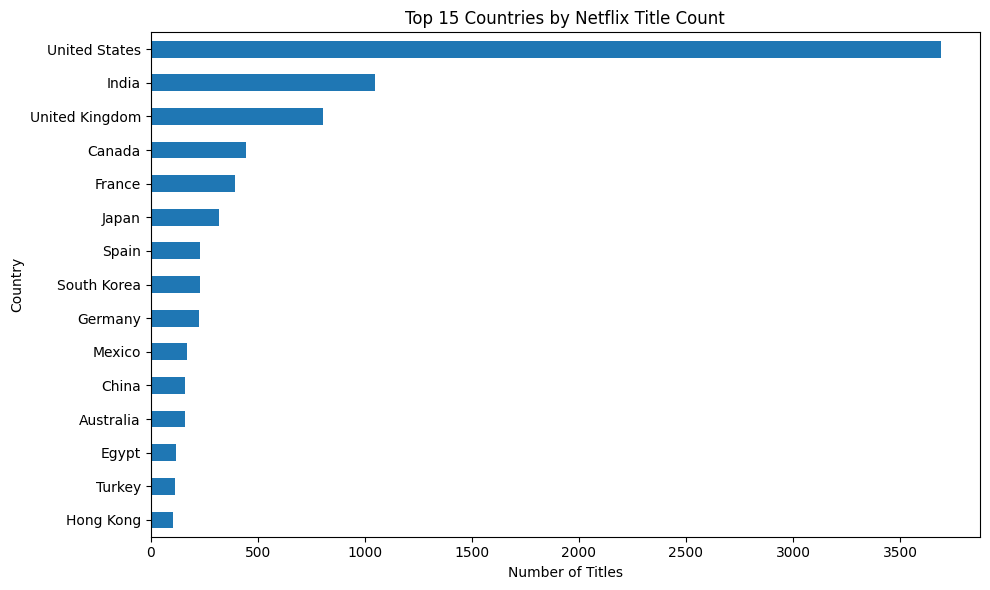

In [4]:
country_counts = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

display(country_counts.head(15).to_frame("Number of Titles"))

print("Most frequent country:", country_counts.index[0])
print("Number of titles:", country_counts.iloc[0])

plt.figure(figsize=(10, 6))
country_counts.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Countries by Netflix Title Count")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

,Number of Titles
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


Most frequent genre: International Movies
Number of titles: 2752


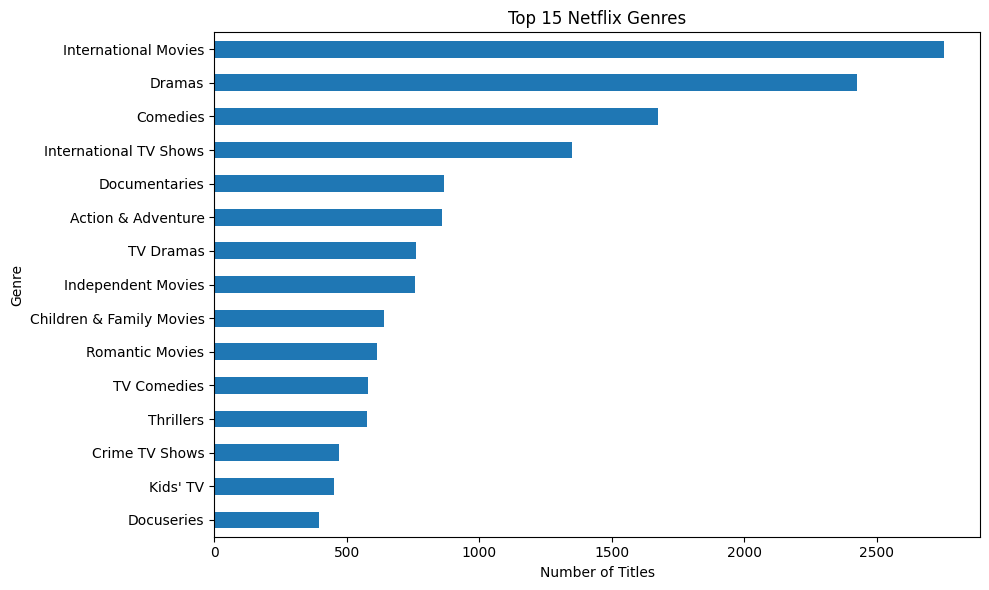

In [5]:
genre_counts = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

display(genre_counts.head(15).to_frame("Number of Titles"))

print("Most frequent genre:", genre_counts.index[0])
print("Number of titles:", genre_counts.iloc[0])

plt.figure(figsize=(10, 6))
genre_counts.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

,Number of Titles
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


Most frequent rating: TV-MA
Number of titles: 3207


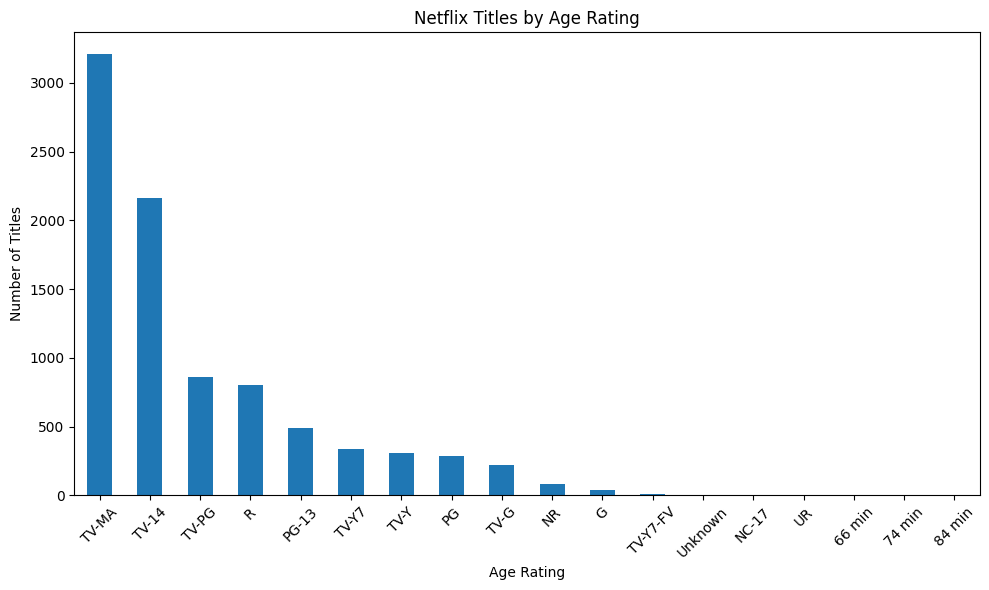

In [6]:
rating_counts = df["rating"].fillna("Unknown").value_counts()

display(rating_counts.to_frame("Number of Titles"))

print("Most frequent rating:", rating_counts.index[0])
print("Number of titles:", rating_counts.iloc[0])

plt.figure(figsize=(10, 6))
rating_counts.plot(kind="bar")
plt.title("Netflix Titles by Age Rating")
plt.xlabel("Age Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
ml_df = df.drop_duplicates().reset_index(drop=True).copy()

# Prepare the three target columns
ml_df["type_target"] = ml_df["type"]

ml_df["rating_target"] = (
    ml_df["rating"].fillna("Unknown")
)

ml_df["genre_target"] = (
    ml_df["listed_in"]
    .fillna("")
    .str.split(", ")
    .str[0]
    .replace("", np.nan)
)

# Build input features without the target columns
feature_columns = [
    "title",
    "director",
    "cast",
    "country",
    "date_added",
    "release_year",
    "description"
]

# Fill missing input values
for col in feature_columns:
    ml_df[col] = ml_df[col].fillna("").astype(str)

# Combine metadata into one text feature
ml_df["input_text"] = ml_df[feature_columns].agg(
    " ".join, axis=1
)

print("Prepared dataset:", ml_df.shape)

display(
    ml_df[[
        "input_text",
        "type_target",
        "rating_target",
        "genre_target"
    ]].head()
)

Prepared dataset: (8807, 16)


,input_text,type_target,rating_target,genre_target
0,Dick Johnson Is Dead Kirsten Johnson United S...,Movie,PG-13,Documentaries
1,"Blood & Water Ama Qamata, Khosi Ngema, Gail M...",TV Show,TV-MA,International TV Shows
2,"Ganglands Julien Leclercq Sami Bouajila, Tracy...",TV Show,TV-MA,Crime TV Shows
3,"Jailbirds New Orleans September 24, 2021 20...",TV Show,TV-MA,Docuseries
4,"Kota Factory Mayur More, Jitendra Kumar, Ranj...",TV Show,TV-MA,International TV Shows


In [8]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    )
}

print("Three models are ready:")
for name in models:
    print("-", name)

Three models are ready:
- Logistic Regression
- Random Forest
- Linear SVM


In [9]:
def create_pipeline(model):

    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=3000,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True
            )
        ),
        ("classifier", model)
    ])

In [10]:
from sklearn.base import clone

all_results = []
trained_models = {}

def run_experiment(target_name, top_classes=None):

    data = ml_df.dropna(subset=[target_name]).copy()

    # Keep the most frequent classes for selected tasks
    if top_classes is not None:
        keep = data[target_name].value_counts().head(
            top_classes
        ).index
        data = data[data[target_name].isin(keep)].copy()

    X = data["input_text"]
    y = data[target_name]

    # Ensure each class has enough samples for stratification
    counts = y.value_counts()
    valid_classes = counts[counts >= 5].index

    data = data[data[target_name].isin(valid_classes)]
    X = data["input_text"]
    y = data[target_name]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    print("\n" + "=" * 65)
    print("TARGET:", target_name)
    print("Training rows:", len(X_train))
    print("Testing rows:", len(X_test))
    print("Number of classes:", y.nunique())
    print("=" * 65)

    for model_name, base_model in models.items():

        pipeline = create_pipeline(clone(base_model))

        start = time.perf_counter()
        pipeline.fit(X_train, y_train)
        train_seconds = time.perf_counter() - start

        start = time.perf_counter()
        y_pred = pipeline.predict(X_test)
        predict_seconds = time.perf_counter() - start

        result = {
            "Target": target_name,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Balanced Accuracy": balanced_accuracy_score(
                y_test, y_pred
            ),
            "Precision (Macro)": precision_score(
                y_test, y_pred,
                average="macro", zero_division=0
            ),
            "Recall (Macro)": recall_score(
                y_test, y_pred,
                average="macro", zero_division=0
            ),
            "F1 (Macro)": f1_score(
                y_test, y_pred,
                average="macro", zero_division=0
            ),
            "F1 (Weighted)": f1_score(
                y_test, y_pred,
                average="weighted", zero_division=0
            ),
            "Training Time (s)": train_seconds,
            "Prediction Time (s)": predict_seconds
        }

        all_results.append(result)

        trained_models[(target_name, model_name)] = {
            "pipeline": pipeline,
            "X_test": X_test,
            "y_test": y_test,
            "y_pred": y_pred,
            "classes": pipeline.named_steps[
                "classifier"
            ].classes_
        }

        print(f"\n--- {model_name} ---")
        print(classification_report(
            y_test, y_pred, zero_division=0
        ))

        print("Accuracy:", round(result["Accuracy"], 4))
        print("Macro F1:", round(result["F1 (Macro)"], 4))
        print("Training time:", round(train_seconds, 2), "seconds")

    return pd.DataFrame(all_results[-len(models):])

In [11]:
type_results = run_experiment("type_target")
display(type_results)


TARGET: type_target
Training rows: 7045
Testing rows: 1762
Number of classes: 2

--- Logistic Regression ---
              precision    recall  f1-score   support

       Movie       0.86      0.81      0.84      1227
     TV Show       0.62      0.70      0.66       535

    accuracy                           0.78      1762
   macro avg       0.74      0.76      0.75      1762
weighted avg       0.79      0.78      0.78      1762

Accuracy: 0.7809
Macro F1: 0.7497
Training time: 2.25 seconds

--- Random Forest ---
              precision    recall  f1-score   support

       Movie       0.84      0.83      0.84      1227
     TV Show       0.63      0.64      0.64       535

    accuracy                           0.78      1762
   macro avg       0.74      0.74      0.74      1762
weighted avg       0.78      0.78      0.78      1762

Accuracy: 0.7764
Macro F1: 0.7373
Training time: 5.22 seconds

--- Linear SVM ---
              precision    recall  f1-score   support

       Movie  

,Target,Model,Accuracy,Balanced Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted),Training Time (s),Prediction Time (s)
0,type_target,Logistic Regression,0.780931,0.759427,0.743290,0.759427,0.749745,0.784440,2.247449,0.285974
1,type_target,Random Forest,0.776390,0.738773,0.735842,0.738773,0.737258,0.777081,5.222970,0.225805
2,type_target,Linear SVM,0.754824,0.729086,0.714500,0.729086,0.720178,0.758847,1.514226,0.144578


In [12]:
rating_results = run_experiment(
    "rating_target",
    top_classes=8
)

display(rating_results)


TARGET: rating_target
Training rows: 6757
Testing rows: 1690
Number of classes: 8

--- Logistic Regression ---
              precision    recall  f1-score   support

          PG       0.26      0.32      0.28        57
       PG-13       0.27      0.41      0.32        98
           R       0.36      0.51      0.42       160
       TV-14       0.52      0.47      0.50       432
       TV-MA       0.66      0.51      0.57       642
       TV-PG       0.27      0.32      0.30       173
        TV-Y       0.59      0.72      0.65        61
       TV-Y7       0.55      0.69      0.61        67

    accuracy                           0.48      1690
   macro avg       0.44      0.49      0.46      1690
weighted avg       0.51      0.48      0.49      1690

Accuracy: 0.4822
Macro F1: 0.4571
Training time: 3.1 seconds

--- Random Forest ---
              precision    recall  f1-score   support

          PG       0.33      0.05      0.09        57
       PG-13       0.23      0.46      0.30 

,Target,Model,Accuracy,Balanced Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted),Training Time (s),Prediction Time (s)
0,rating_target,Logistic Regression,0.482249,0.492819,0.435607,0.492819,0.457084,0.491224,3.103793,0.208662
1,rating_target,Random Forest,0.392308,0.368169,0.381295,0.368169,0.345435,0.387332,4.254388,0.222172
2,rating_target,Linear SVM,0.476331,0.459319,0.435875,0.459319,0.446217,0.480613,2.391641,0.246150


In [13]:
genre_results = run_experiment(
    "genre_target",
    top_classes=10
)

display(genre_results)


TARGET: genre_target
Training rows: 5818
Testing rows: 1455
Number of classes: 10

--- Logistic Regression ---
                          precision    recall  f1-score   support

      Action & Adventure       0.52      0.49      0.51       172
Children & Family Movies       0.49      0.67      0.57       121
                Comedies       0.56      0.51      0.53       242
          Crime TV Shows       0.41      0.53      0.46        80
           Documentaries       0.80      0.80      0.80       166
                  Dramas       0.58      0.47      0.52       320
           Horror Movies       0.40      0.51      0.45        55
  International TV Shows       0.56      0.57      0.57       155
                Kids' TV       0.67      0.64      0.65        77
         Stand-Up Comedy       0.85      0.96      0.90        67

                accuracy                           0.58      1455
               macro avg       0.58      0.61      0.60      1455
            weighted avg    

,Target,Model,Accuracy,Balanced Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted),Training Time (s),Prediction Time (s)
0,genre_target,Logistic Regression,0.581443,0.614896,0.584673,0.614896,0.596000,0.580732,4.782786,0.292399
1,genre_target,Random Forest,0.428179,0.480142,0.445083,0.480142,0.434148,0.404261,4.544202,0.213498
2,genre_target,Linear SVM,0.576632,0.595294,0.581717,0.595294,0.587030,0.575153,1.545920,0.119621


In [14]:
comparison_df = pd.DataFrame(all_results)

display(
    comparison_df.sort_values(
        ["Target", "F1 (Macro)"],
        ascending=[True, False]
    ).round(4)
)

,Target,Model,Accuracy,Balanced Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted),Training Time (s),Prediction Time (s)
6,genre_target,Logistic Regression,0.5814,0.6149,0.5847,0.6149,0.5960,0.5807,4.7828,0.2924
8,genre_target,Linear SVM,0.5766,0.5953,0.5817,0.5953,0.5870,0.5752,1.5459,0.1196
7,genre_target,Random Forest,0.4282,0.4801,0.4451,0.4801,0.4341,0.4043,4.5442,0.2135
3,rating_target,Logistic Regression,0.4822,0.4928,0.4356,0.4928,0.4571,0.4912,3.1038,0.2087
5,rating_target,Linear SVM,0.4763,0.4593,0.4359,0.4593,0.4462,0.4806,2.3916,0.2461
4,rating_target,Random Forest,0.3923,0.3682,0.3813,0.3682,0.3454,0.3873,4.2544,0.2222
0,type_target,Logistic Regression,0.7809,0.7594,0.7433,0.7594,0.7497,0.7844,2.2474,0.2860
1,type_target,Random Forest,0.7764,0.7388,0.7358,0.7388,0.7373,0.7771,5.2230,0.2258
2,type_target,Linear SVM,0.7548,0.7291,0.7145,0.7291,0.7202,0.7588,1.5142,0.1446


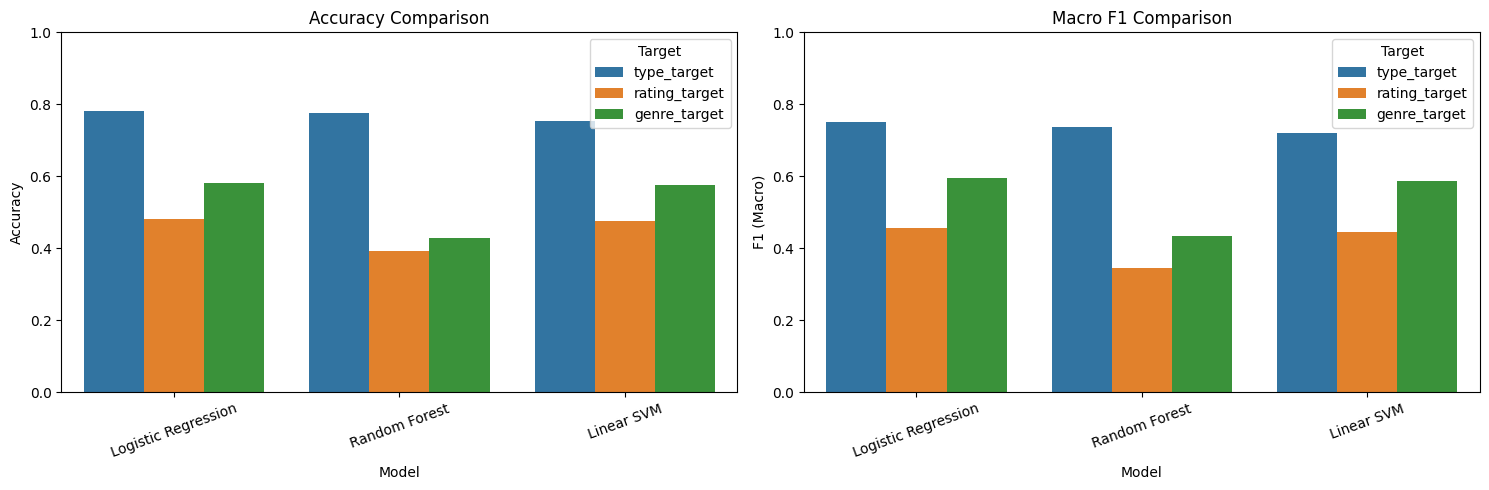

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy",
    hue="Target",
    ax=axes[0]
)
axes[0].set_title("Accuracy Comparison")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=comparison_df,
    x="Model",
    y="F1 (Macro)",
    hue="Target",
    ax=axes[1]
)
axes[1].set_title("Macro F1 Comparison")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [16]:
def plot_confusion(target_name, model_name):

    result = trained_models[(target_name, model_name)]

    y_test = result["y_test"]
    y_pred = result["y_pred"]
    labels = result["classes"]

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=labels
    )

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.title(f"Confusion Matrix: {target_name} — {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

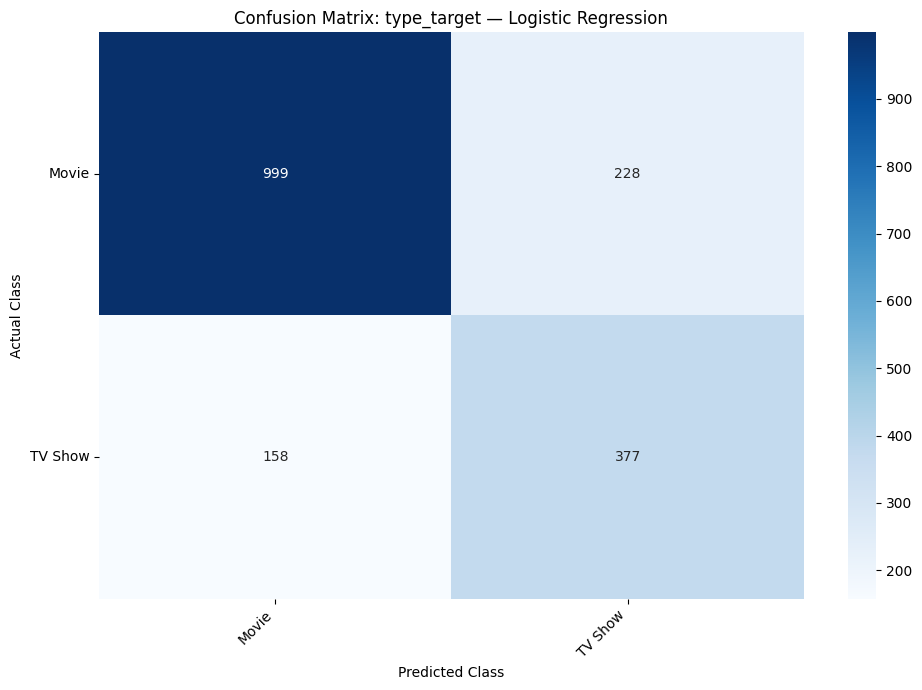

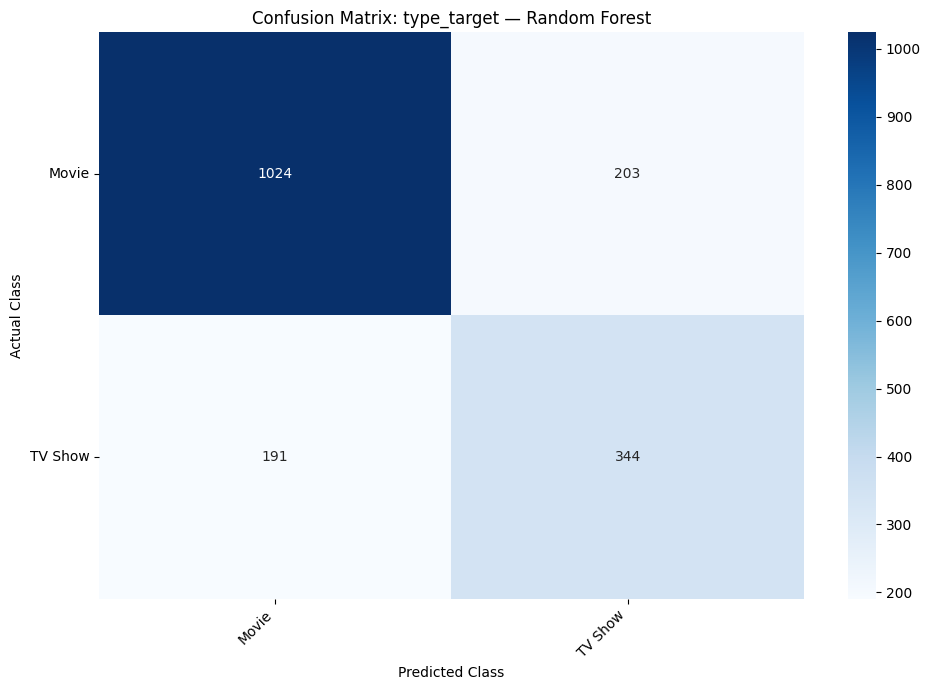

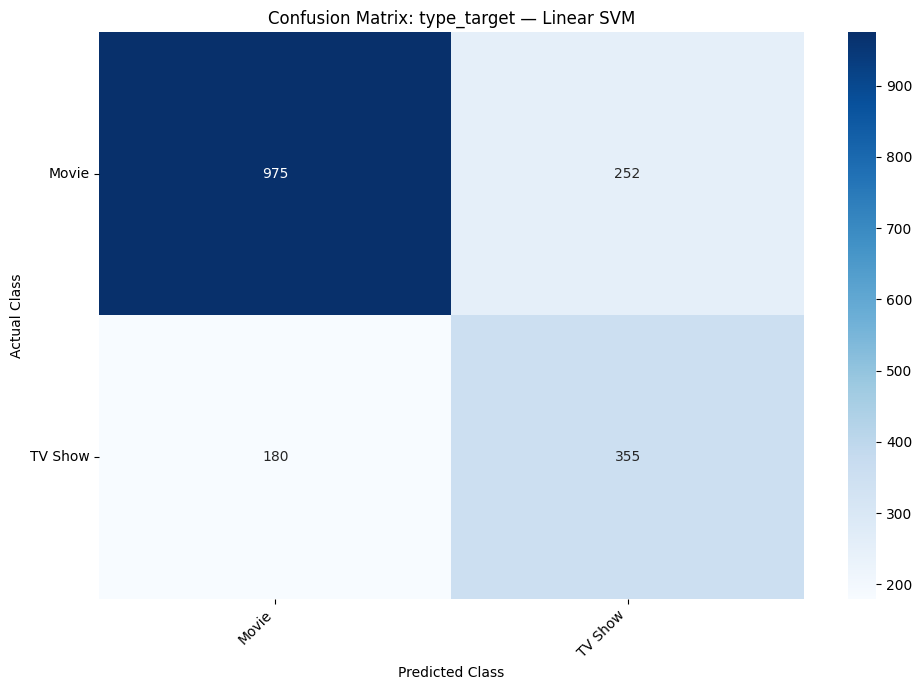

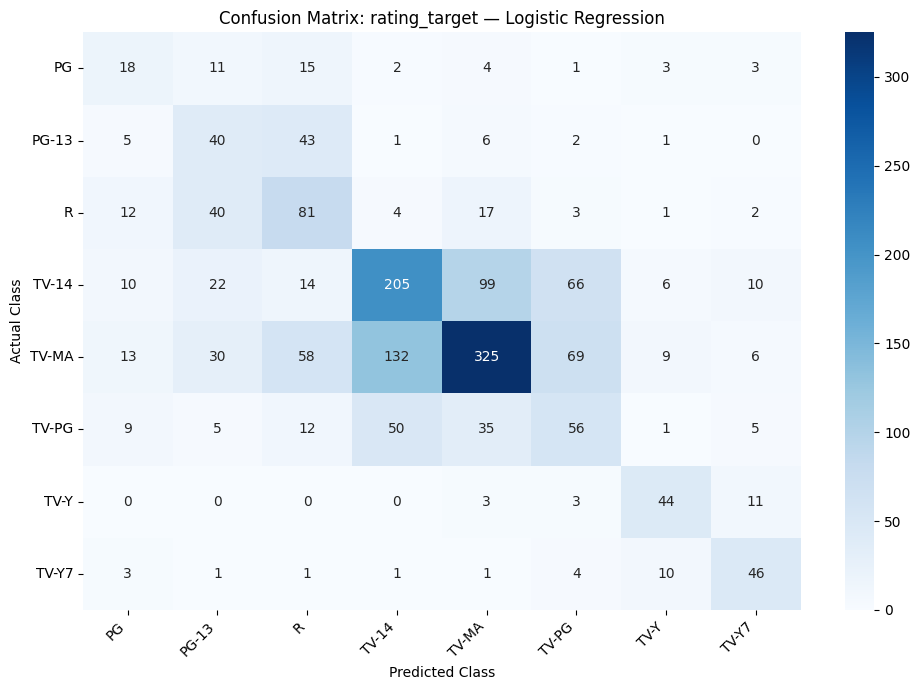

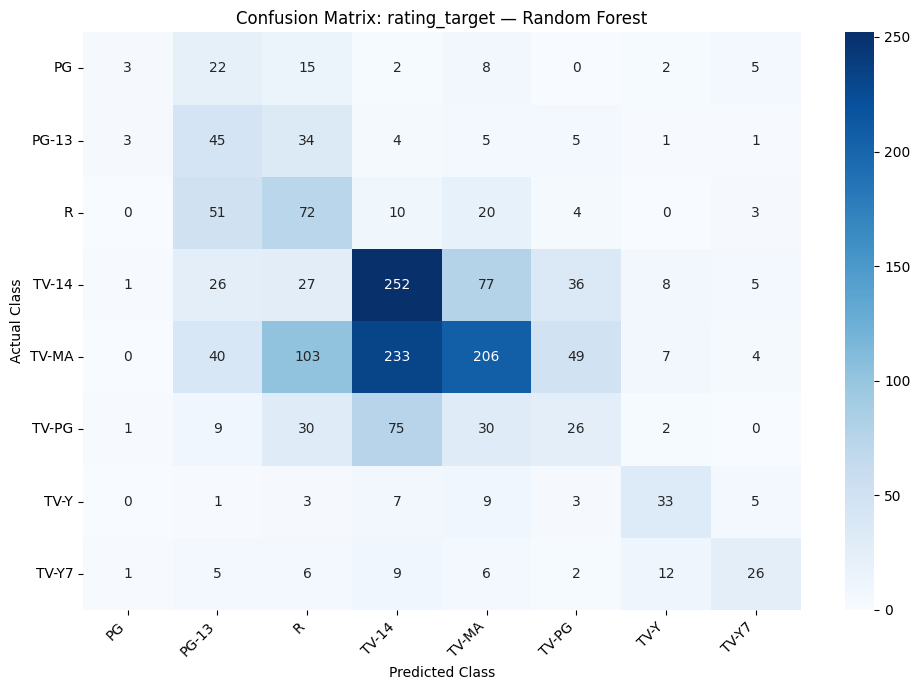

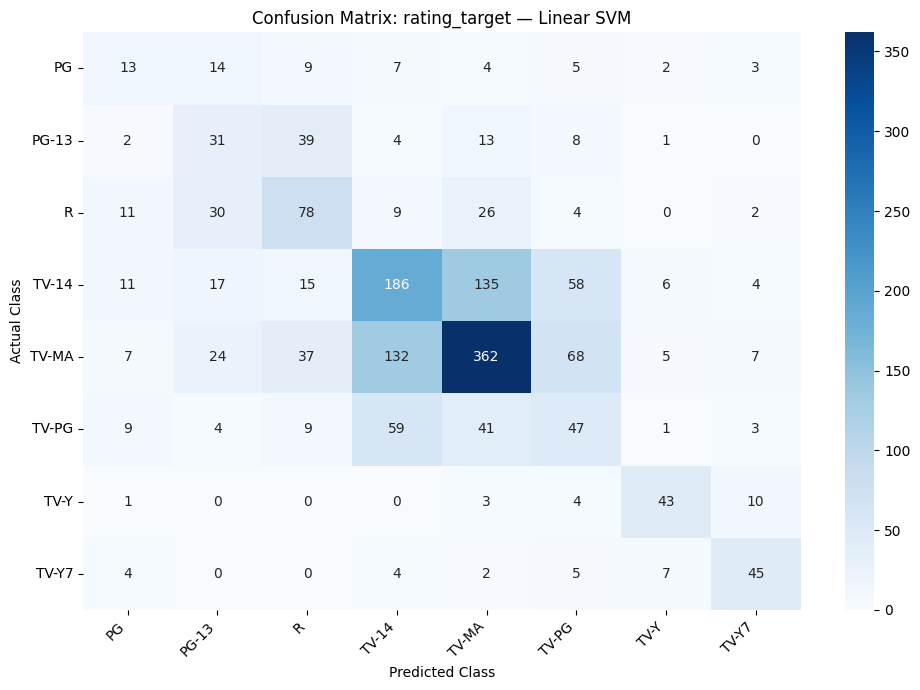

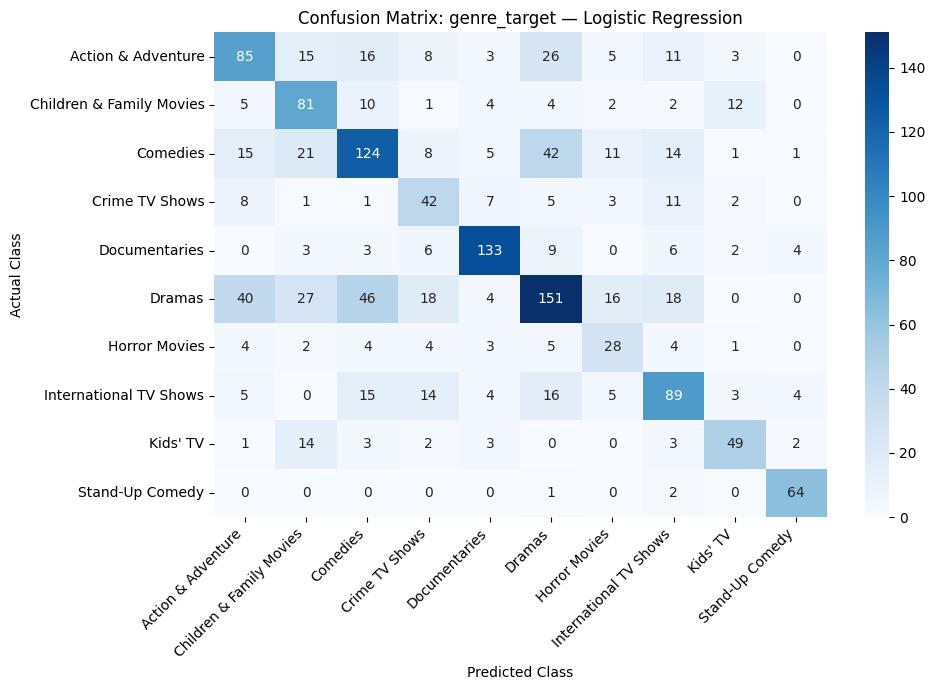

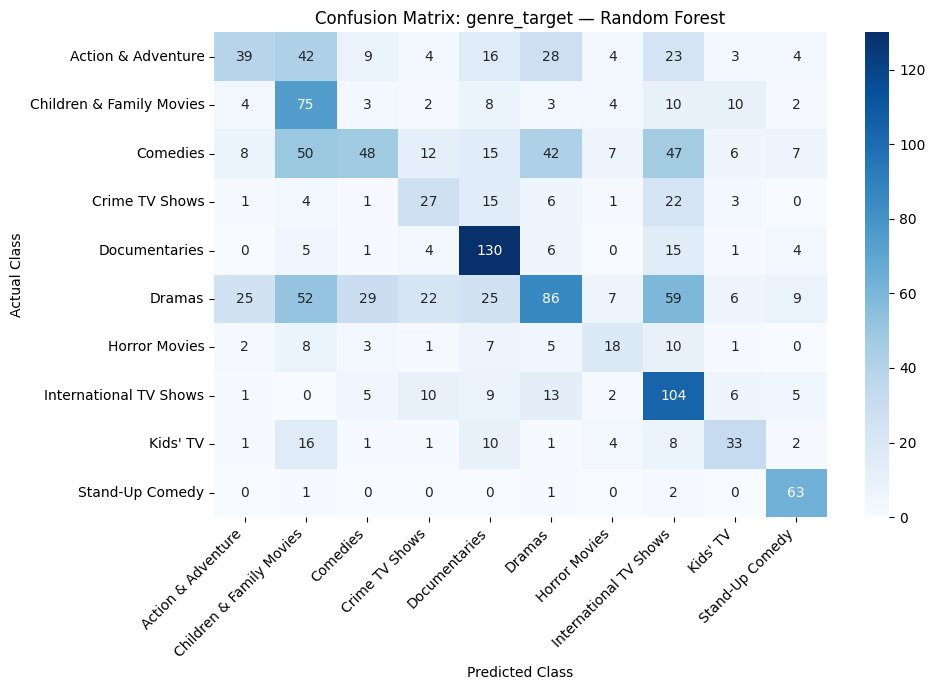

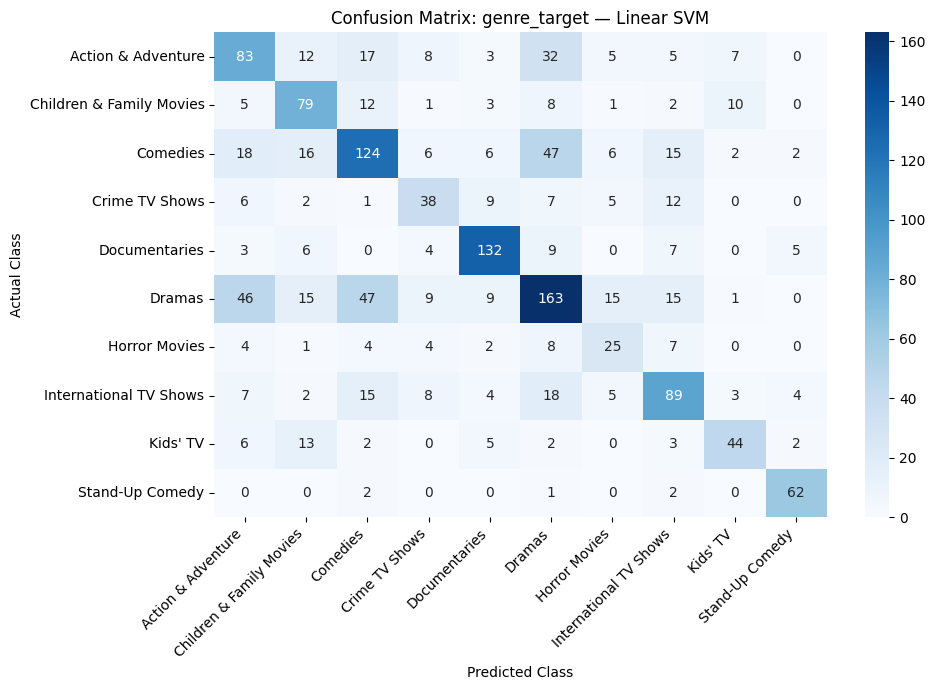

In [ ]:
for target in [
    "type_target",
    "rating_target",
    "genre_target"
]:
    for model_name in models:
        plot_confusion(target, model_name)

In [17]:
from sklearn.preprocessing import label_binarize

def get_model_scores(pipeline, X_test):
    classifier = pipeline.named_steps["classifier"]

    if hasattr(classifier, "predict_proba"):
        return pipeline.predict_proba(X_test)

    return pipeline.decision_function(X_test)


def plot_roc(target_name, model_name):

    result = trained_models[(target_name, model_name)]

    pipeline = result["pipeline"]
    X_test = result["X_test"]
    y_test = result["y_test"]
    classes = result["classes"]

    scores = get_model_scores(pipeline, X_test)

    plt.figure(figsize=(8, 6))

    if len(classes) == 2:
        # Binary ROC
        positive_scores = (
            scores[:, 1] if scores.ndim == 2 else scores
        )
        y_binary = (y_test == classes[1]).astype(int)

        fpr, tpr, _ = roc_curve(y_binary, positive_scores)
        score_auc = auc(fpr, tpr)

        plt.plot(
            fpr, tpr,
            label=f"AUC = {score_auc:.3f}"
        )

    else:
        # Multiclass one-vs-rest ROC
        y_binary = label_binarize(y_test, classes=classes)

        for i, label in enumerate(classes):
            fpr, tpr, _ = roc_curve(
                y_binary[:, i], scores[:, i]
            )
            score_auc = auc(fpr, tpr)

            plt.plot(
                fpr, tpr,
                label=f"{label} (AUC={score_auc:.2f})"
            )

        macro_auc = roc_auc_score(
            y_binary, scores, average="macro"
        )
        print(
            f"{target_name} / {model_name} macro ROC-AUC:",
            round(macro_auc, 4)
        )

    plt.plot([0, 1], [0, 1], "k--", label="Chance level")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve: {target_name} — {model_name}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

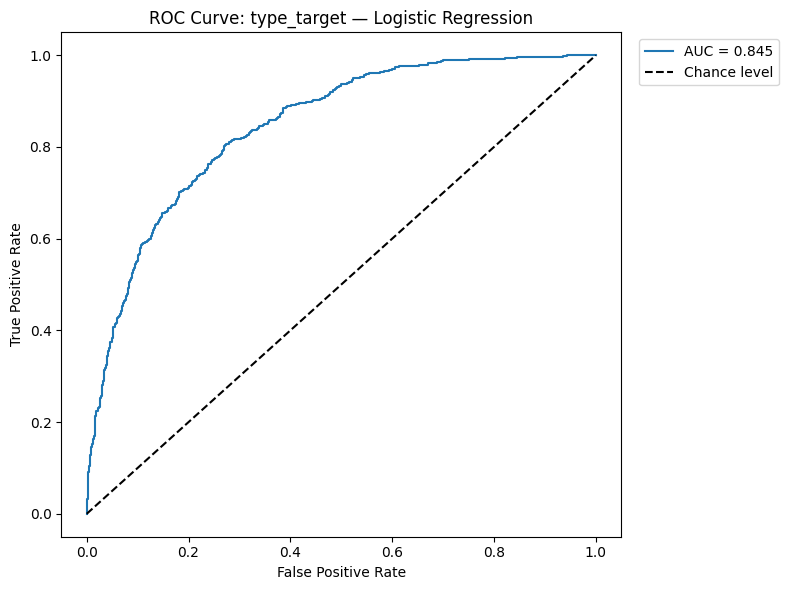

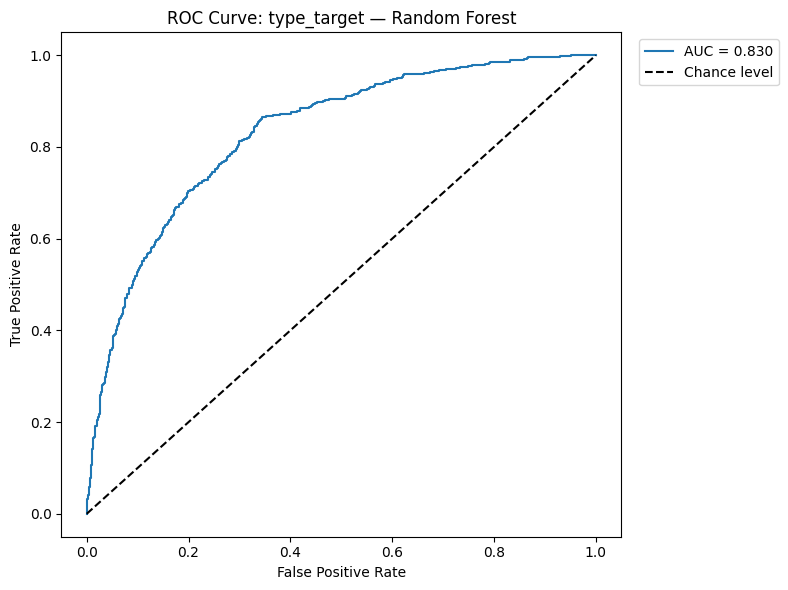

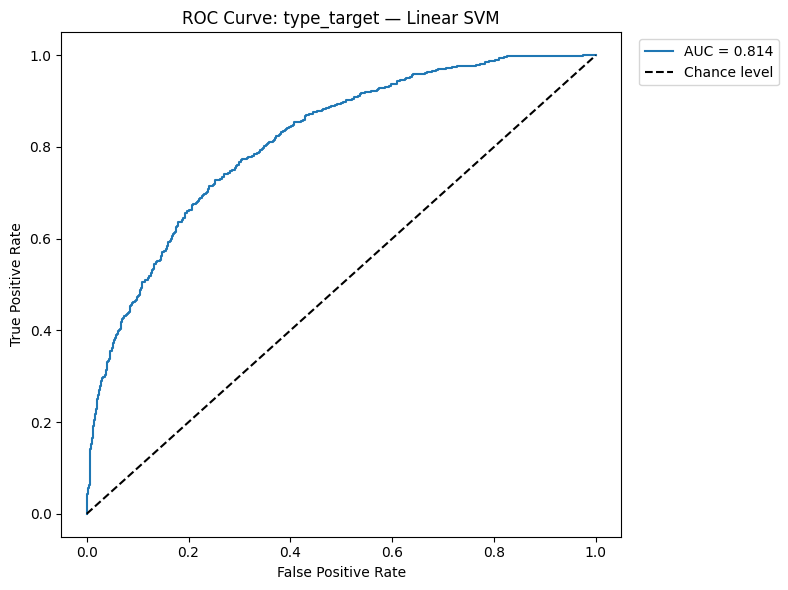

rating_target / Logistic Regression macro ROC-AUC: 0.8484


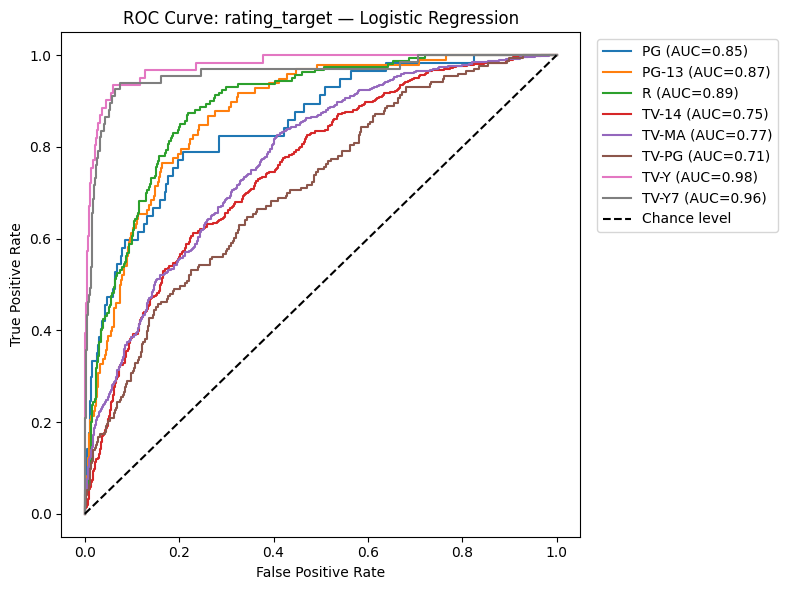

rating_target / Random Forest macro ROC-AUC: 0.8013


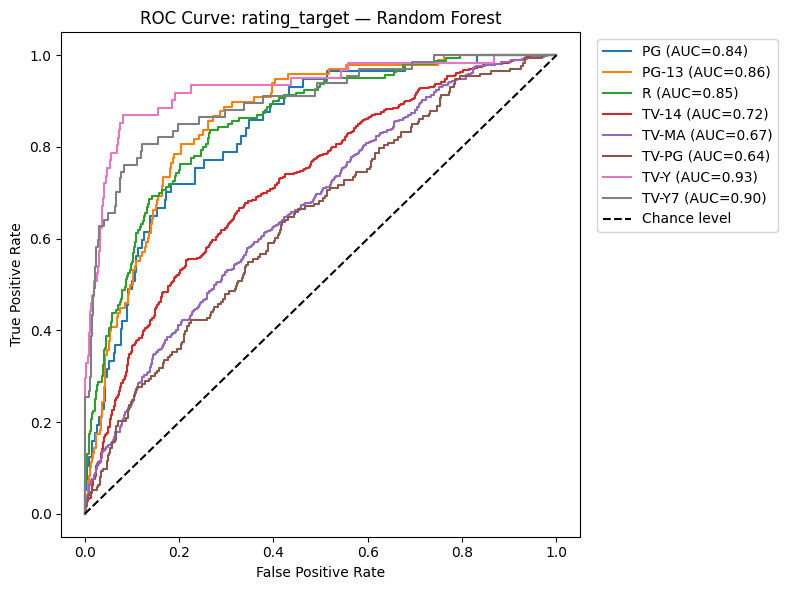

rating_target / Linear SVM macro ROC-AUC: 0.8175


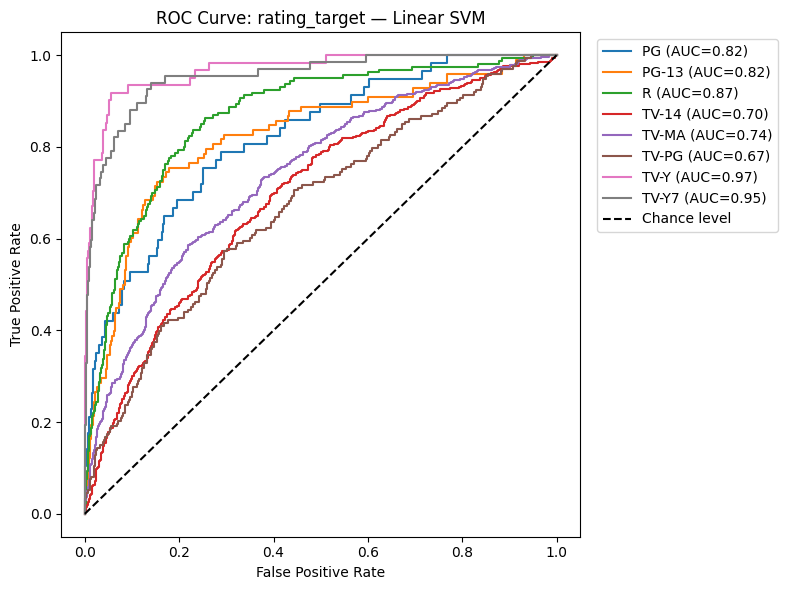

genre_target / Logistic Regression macro ROC-AUC: 0.9054


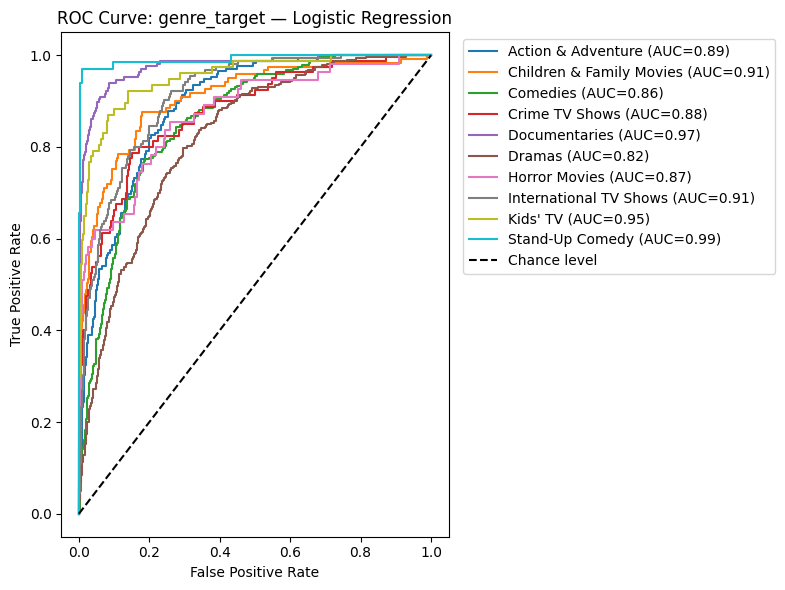

genre_target / Random Forest macro ROC-AUC: 0.8442


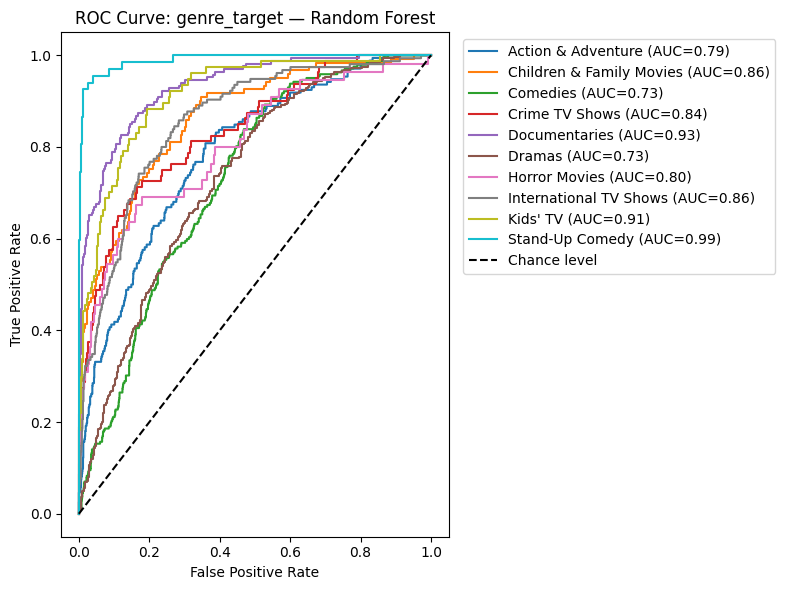

genre_target / Linear SVM macro ROC-AUC: 0.8854


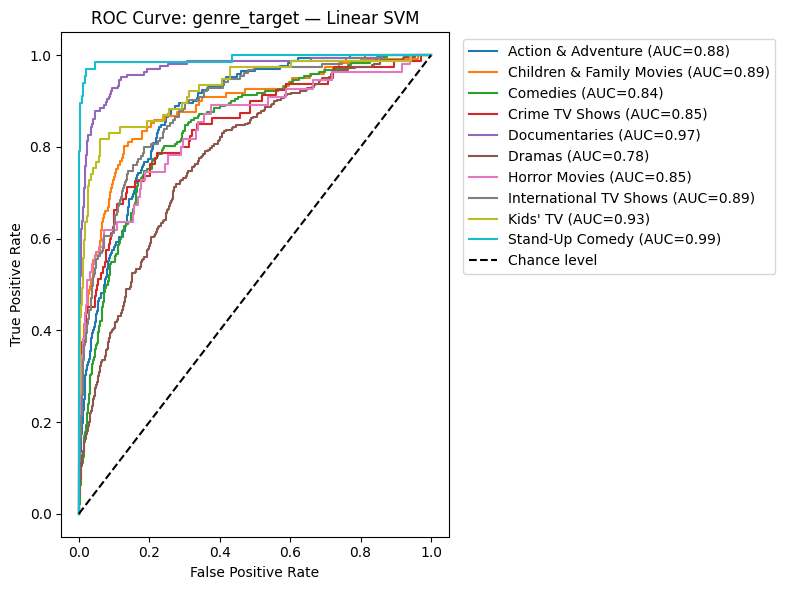

In [18]:
for target in [
    "type_target",
    "rating_target",
    "genre_target"
]:
    for model_name in models:
        plot_roc(target, model_name)

In [19]:
def plot_precision_recall(target_name, model_name):

    result = trained_models[(target_name, model_name)]

    pipeline = result["pipeline"]
    X_test = result["X_test"]
    y_test = result["y_test"]
    classes = result["classes"]

    scores = get_model_scores(pipeline, X_test)

    plt.figure(figsize=(8, 6))

    if len(classes) == 2:
        y_binary = (y_test == classes[1]).astype(int)
        positive_scores = (
            scores[:, 1] if scores.ndim == 2 else scores
        )

        precision, recall, _ = precision_recall_curve(
            y_binary, positive_scores
        )

        ap = average_precision_score(y_binary, positive_scores)

        plt.plot(
            recall, precision,
            label=f"AP = {ap:.3f}"
        )

    else:
        y_binary = label_binarize(y_test, classes=classes)

        for i, label in enumerate(classes):
            precision, recall, _ = precision_recall_curve(
                y_binary[:, i], scores[:, i]
            )

            ap = average_precision_score(
                y_binary[:, i], scores[:, i]
            )

            plt.plot(
                recall, precision,
                label=f"{label} (AP={ap:.2f})"
            )

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall: {target_name} — {model_name}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

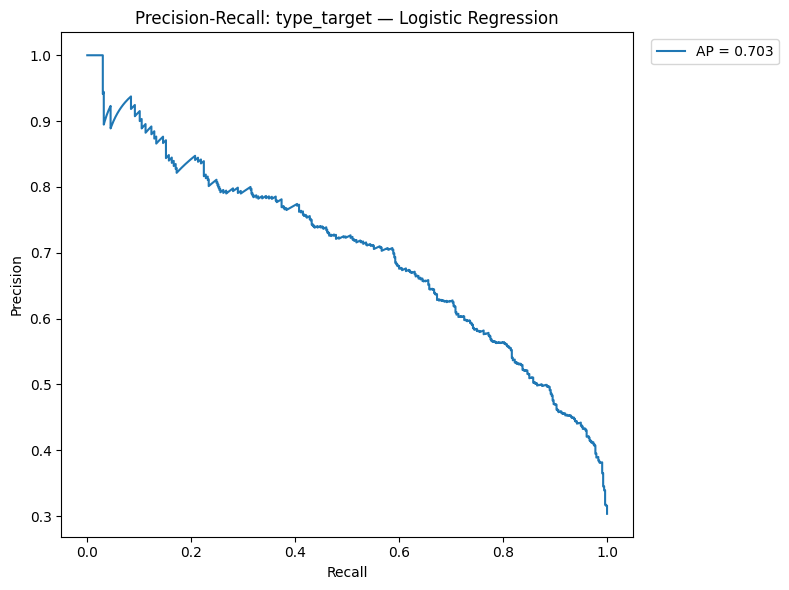

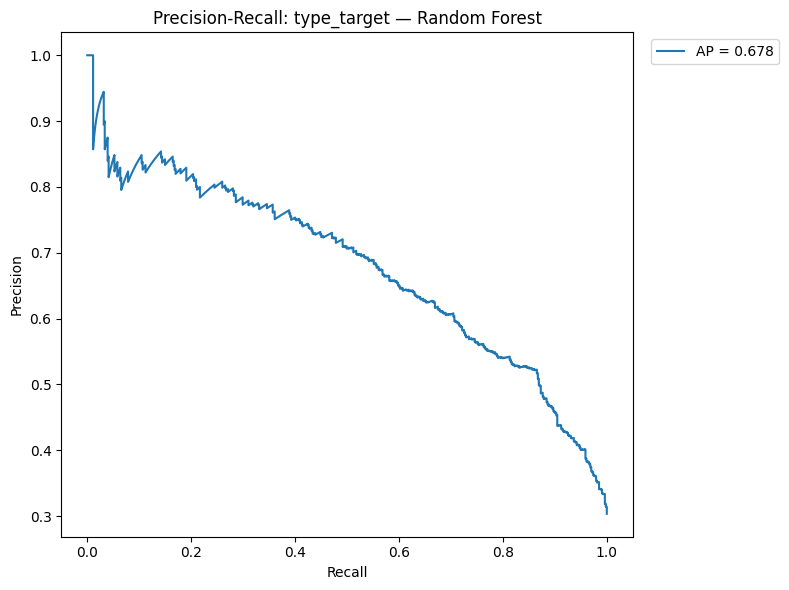

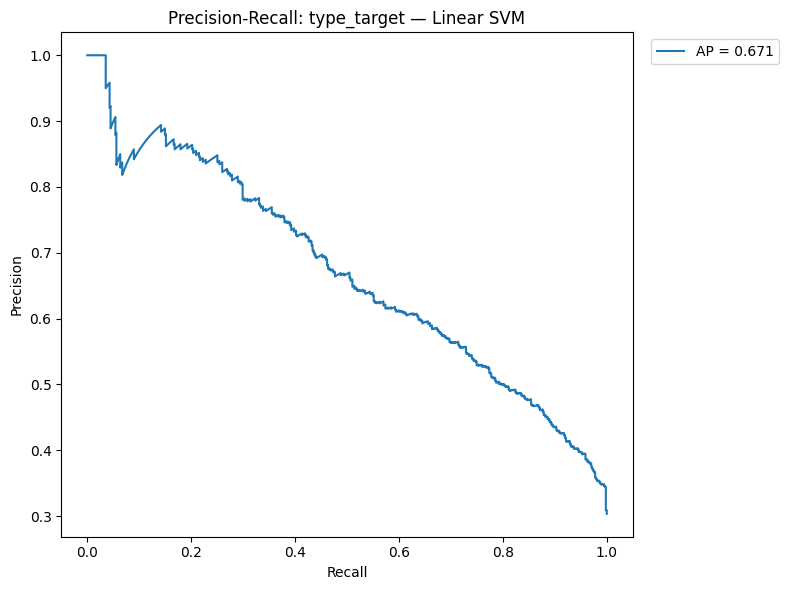

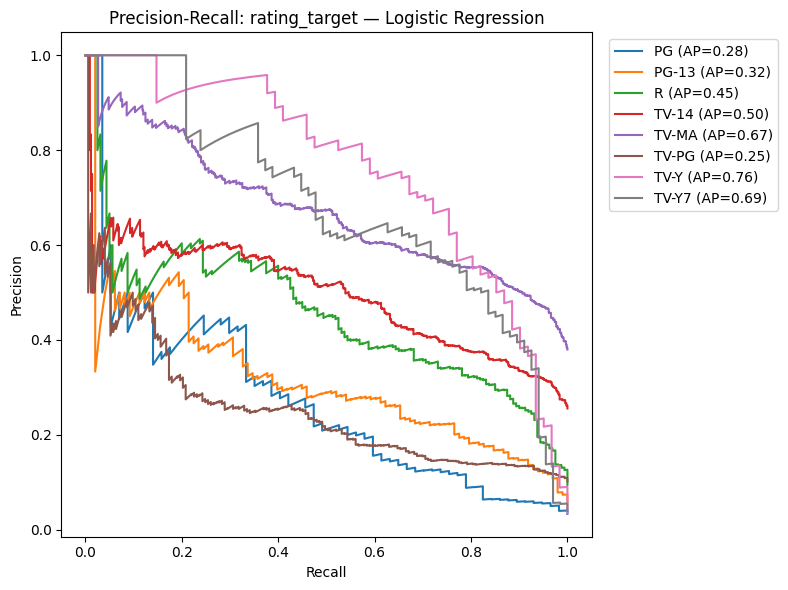

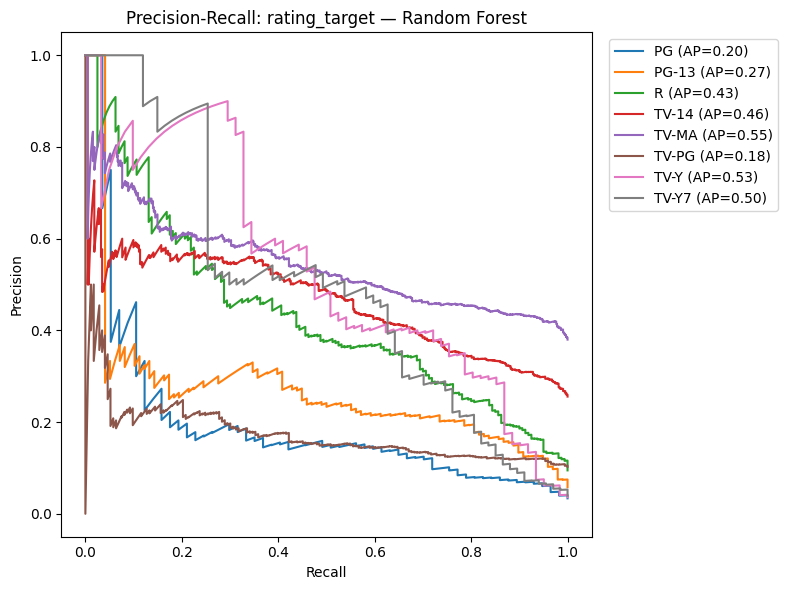

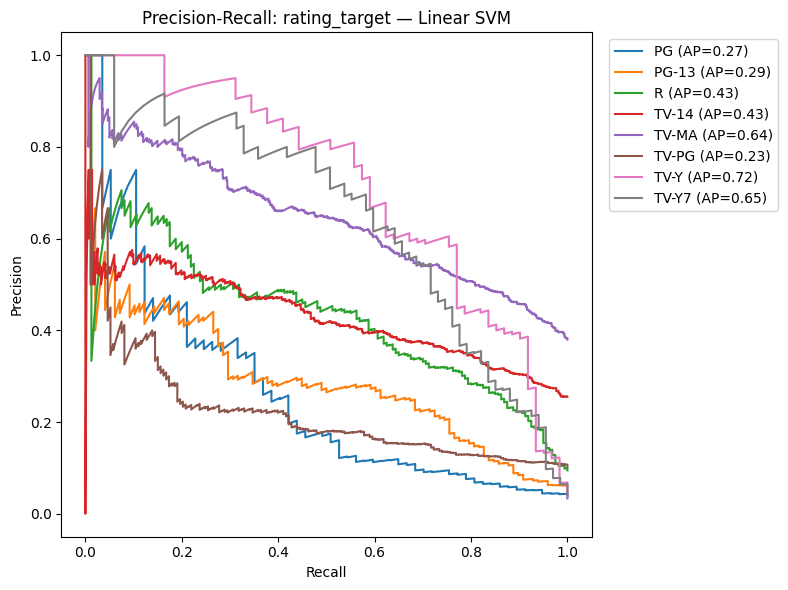

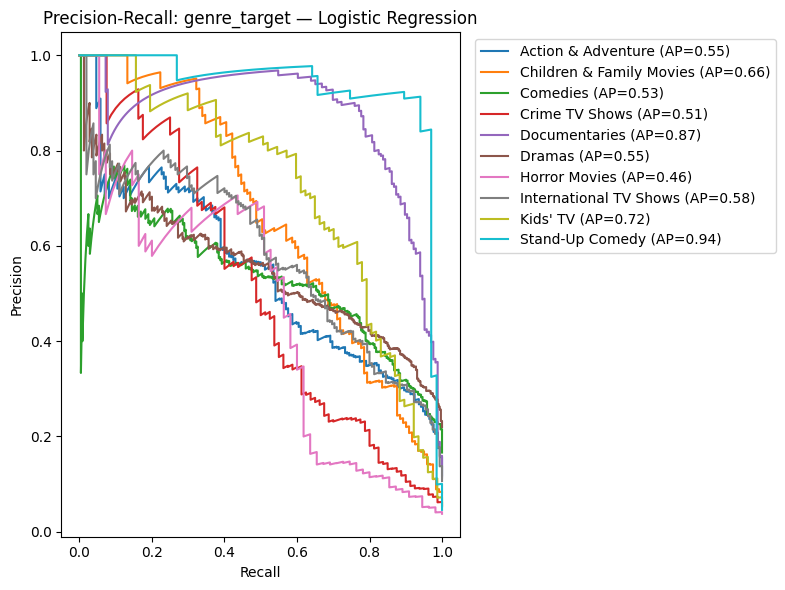

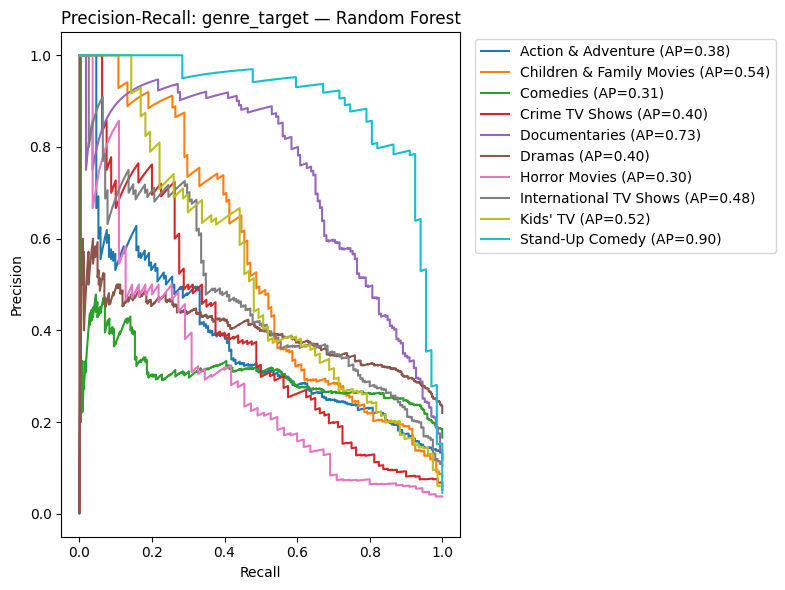

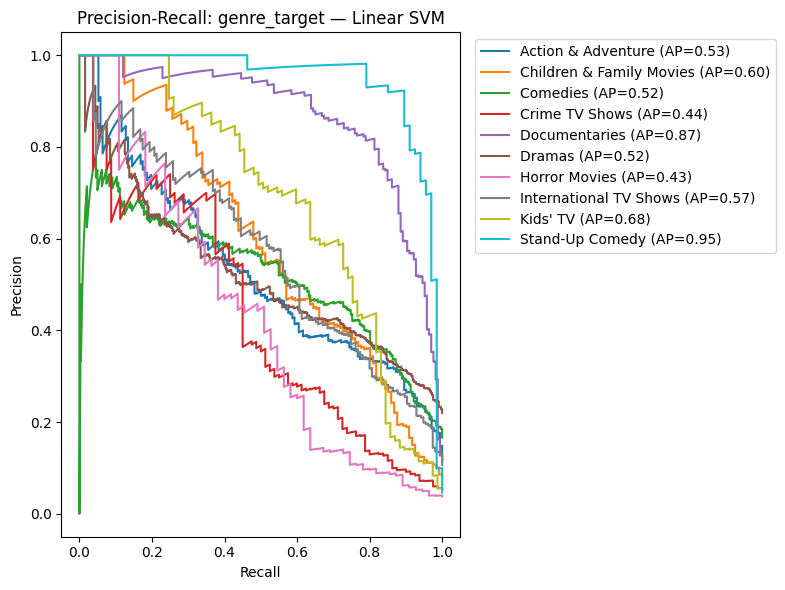

In [20]:
for target in [
    "type_target",
    "rating_target",
    "genre_target"
]:
    for model_name in models:
        plot_precision_recall(target, model_name)

In [21]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

target_class_limits = {
    "type_target": None,
    "rating_target": 8,
    "genre_target": 10
}

cv_results = []

for target_name, top_classes in target_class_limits.items():

    data = ml_df.dropna(subset=[target_name]).copy()

    if top_classes is not None:
        keep = data[target_name].value_counts().head(
            top_classes
        ).index
        data = data[data[target_name].isin(keep)]

    counts = data[target_name].value_counts()
    valid_classes = counts[counts >= 5].index
    data = data[data[target_name].isin(valid_classes)]

    X_cv = data["input_text"]
    y_cv = data[target_name]

    for model_name, base_model in models.items():

        pipeline = create_pipeline(clone(base_model))

        scores = cross_val_score(
            pipeline,
            X_cv,
            y_cv,
            cv=cv,
            scoring="f1_macro",
            n_jobs=1
        )

        cv_results.append({
            "Target": target_name,
            "Model": model_name,
            "Mean CV Macro F1": scores.mean(),
            "Std CV Macro F1": scores.std(),
            "Fold 1": scores[0],
            "Fold 2": scores[1],
            "Fold 3": scores[2],
            "Fold 4": scores[3],
            "Fold 5": scores[4]
        })

cv_df = pd.DataFrame(cv_results)

display(
    cv_df.sort_values(
        ["Target", "Mean CV Macro F1"],
        ascending=[True, False]
    ).round(4)
)

,Target,Model,Mean CV Macro F1,Std CV Macro F1,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
6,genre_target,Logistic Regression,0.5933,0.0092,0.6012,0.5914,0.5764,0.5968,0.6010
8,genre_target,Linear SVM,0.5671,0.0095,0.5670,0.5790,0.5531,0.5607,0.5758
7,genre_target,Random Forest,0.4489,0.0074,0.4547,0.4512,0.4525,0.4343,0.4518
3,rating_target,Logistic Regression,0.4581,0.0058,0.4529,0.4635,0.4514,0.4567,0.4661
5,rating_target,Linear SVM,0.4431,0.0094,0.4367,0.4608,0.4338,0.4428,0.4415
4,rating_target,Random Forest,0.3699,0.0115,0.3605,0.3599,0.3728,0.3910,0.3652
0,type_target,Logistic Regression,0.7597,0.0124,0.7406,0.7505,0.7637,0.7708,0.7732
2,type_target,Linear SVM,0.7358,0.0124,0.7199,0.7235,0.7370,0.7496,0.7489
1,type_target,Random Forest,0.7333,0.0151,0.7103,0.7237,0.7404,0.7543,0.7377


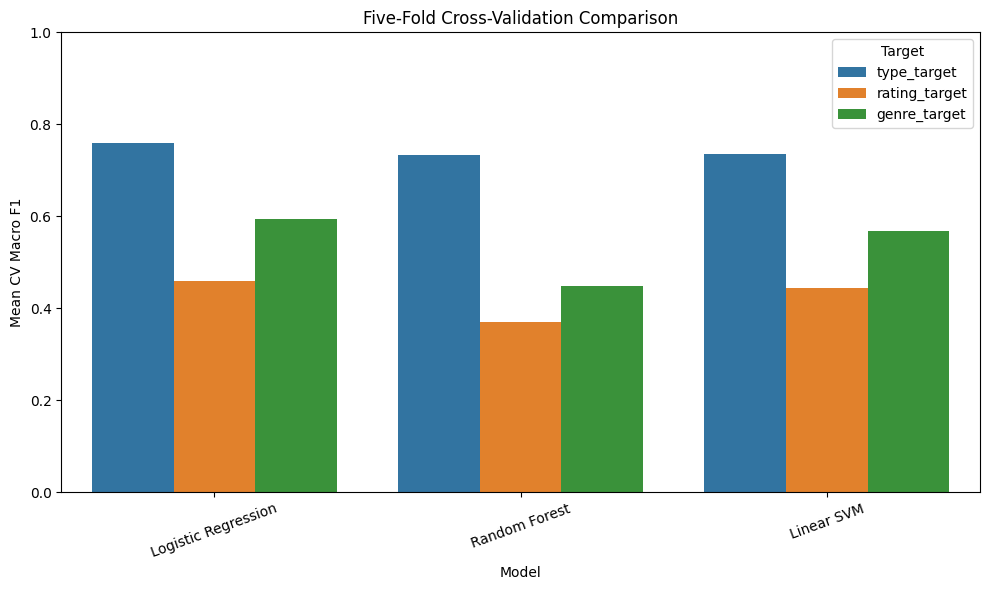

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_df,
    x="Model",
    y="Mean CV Macro F1",
    hue="Target"
)

plt.title("Five-Fold Cross-Validation Comparison")
plt.ylabel("Mean CV Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

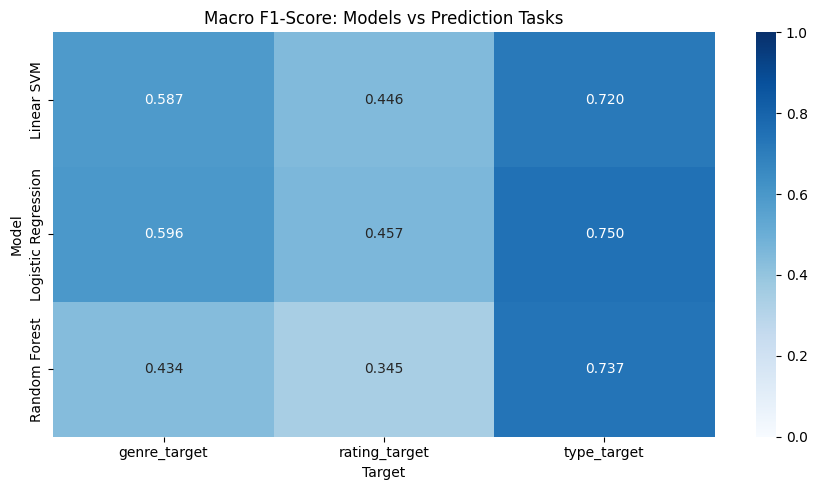

In [23]:
heatmap_data = comparison_df.pivot(
    index="Model",
    columns="Target",
    values="F1 (Macro)"
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title("Macro F1-Score: Models vs Prediction Tasks")
plt.tight_layout()
plt.show()

In [24]:
best_test_models = (
    comparison_df.sort_values("F1 (Macro)", ascending=False)
    .groupby("Target")
    .head(1)
    .reset_index(drop=True)
)

display(
    best_test_models[
        [
            "Target",
            "Model",
            "Accuracy",
            "Balanced Accuracy",
            "Precision (Macro)",
            "Recall (Macro)",
            "F1 (Macro)",
            "F1 (Weighted)",
            "Training Time (s)",
            "Prediction Time (s)"
        ]
    ].round(4)
)

,Target,Model,Accuracy,Balanced Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted),Training Time (s),Prediction Time (s)
0,type_target,Logistic Regression,0.7809,0.7594,0.7433,0.7594,0.7497,0.7844,2.2474,0.2860
1,genre_target,Logistic Regression,0.5814,0.6149,0.5847,0.6149,0.5960,0.5807,4.7828,0.2924
2,rating_target,Logistic Regression,0.4822,0.4928,0.4356,0.4928,0.4571,0.4912,3.1038,0.2087


In [25]:
with pd.ExcelWriter("Netflix_ML_Evaluation.xlsx") as writer:

    comparison_df.to_excel(
        writer,
        sheet_name="Test Set Comparison",
        index=False
    )

    cv_df.to_excel(
        writer,
        sheet_name="Cross Validation",
        index=False
    )

    best_test_models.to_excel(
        writer,
        sheet_name="Best Test Results",
        index=False
    )

    pd.DataFrame({
        "Country": country_counts.index,
        "Title Count": country_counts.values
    }).to_excel(
        writer,
        sheet_name="Country Analysis",
        index=False
    )

    pd.DataFrame({
        "Genre": genre_counts.index,
        "Title Count": genre_counts.values
    }).to_excel(
        writer,
        sheet_name="Genre Analysis",
        index=False
    )

    pd.DataFrame({
        "Rating": rating_counts.index,
        "Title Count": rating_counts.values
    }).to_excel(
        writer,
        sheet_name="Rating Analysis",
        index=False
    )

print("Evaluation results exported successfully!")

files.download("Netflix_ML_Evaluation.xlsx")

Evaluation results exported successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>